/home/tkmcg/neuron-env/lib/python3.12/site-packages/pyNN/neuron/__init__.py:14: UserWarning: mpi4py not available
  warnings.warn("mpi4py not available")


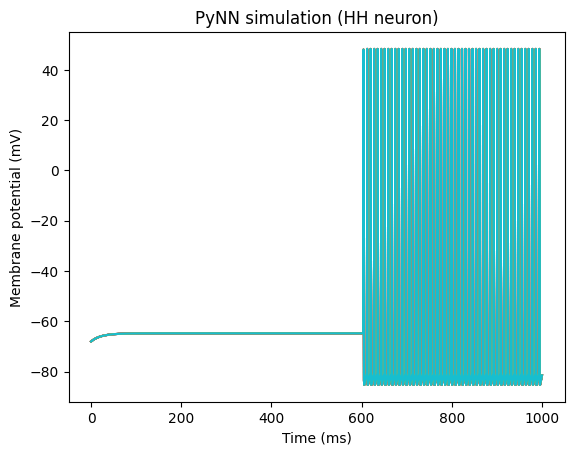

In [1]:
##### Add in the STN neurons and change the geometry to match the coupling project with DC current ####
import pyNN.neuron as sim
import matplotlib.pyplot as plt
from pyNN import space
from pyNN.random import RandomDistribution, NumpyRNG
import numpy as np
from pyNN.neuron import Projection, StaticSynapse, FixedNumberPreConnector
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

v_init = -68
rng_seed = 856

############ Setup the simulation##########
sim.setup(timestep=0.01)

###########Set up the structure ############
cortical_space = space.RandomStructure(boundary=space.Cuboid(8000, 8000, 8000))
STN_space = space.RandomStructure(boundary=space.Cuboid(4000,4000,12000))

###########set up the neuron type##############
cortical_type = sim.HH_cond_exp()
STN_type = sim.HH_cond_exp()

########## create a population of neurons ###############
cortical_pop = sim.Population(100, cortical_type, structure=cortical_space, initial_values={'v': v_init}, label="Cortical neurons")
STN_pop = sim.Population(100, STN_type, structure=STN_space, initial_values={'v': v_init}, label="STN neurons")

########  offset the STN neurons ############
for STN_cell in STN_pop:
    STN_cell.position[2] = STN_cell.position[2] + 6000

##### check no neurons in the no go area####
# stn neurons
for STN_cell in STN_pop:
    while (
        (np.abs(STN_cell.position[0]) > 4000)
        or ((np.abs(STN_cell.position[1]) > 4000))
        or (np.abs(STN_cell.position[2]) > 12000)
    ) or (
        (-150 < STN_cell.position[0] < 150)
            and (-317.5 < STN_cell.position[2] < 317.5)
        ):
            STN_cell.position = STN_space.generate_positions(1).flatten()

for Cortical_cell in cortical_pop:
    while (
        (np.abs(Cortical_cell.position[0]) > 8000)
        or ((np.abs(Cortical_cell.position[1]) > 8000))
         or ((np.abs(Cortical_cell.position[2]) > 8000))
        ) or (
            (-150 < Cortical_cell.position[0] < 150)
            and (-67.5 < Cortical_cell.position[2] < 567.5) #z limit -317.5 < z < 317.5 but offset by +250
        ):
        Cortical_cell.position = cortical_space.generate_positions(1).flatten()

############ set up the current ##############
start = 600
stop = 1000
cortical_pop.inject(sim.DCSource(start=start, stop=stop, amplitude=1))

############# make the connections ############
syn_CorticalCollateralSTN = StaticSynapse(weight=0.12, delay=1)

prj_CorticalSTN = Projection(
    cortical_pop,
    STN_pop,
    FixedNumberPreConnector(n=5, allow_self_connections=False),
    syn_CorticalCollateralSTN,
    source="collateral(0.5)",
    receptor_type="excitatory",
)

######## Record membrane potential from the STN neurons #############
#cortical_pop.record('v')

STN_pop.sample(10).record('v')

######### Run the simulation ###########
sim.run(1000)

############ Get and plot data ############
data = STN_pop.get_data().segments[0]
vm = data.filter(name="v")[0]

plt.plot(vm.times, vm)
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("PyNN simulation (HH neuron)")
plt.show()

####### Clean up ###########
sim.end()

In [5]:
#make fake comsol data - making sure to encompass everything
x_vals = np.random.uniform(-4000, 12000, size=20)
y_vals = np.random.uniform(-4000, 12000, size=20)
z_vals = np.random.uniform(-4000, 12000, size=20)

with open("exStimVoltProf.txt", "w") as f:
    for x in x_vals:
        for y in y_vals:
            for z in z_vals:
                V = x+y+z  # just a made-up smooth voltage profile
                f.write(f"{x:.1f} {y:.1f} {z:.1f} {V:.6f}\n")

/tmp/ipykernel_5484/319721725.py:111: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('exStimVoltProf.txt', names=column_names, comment='%', delim_whitespace=True)


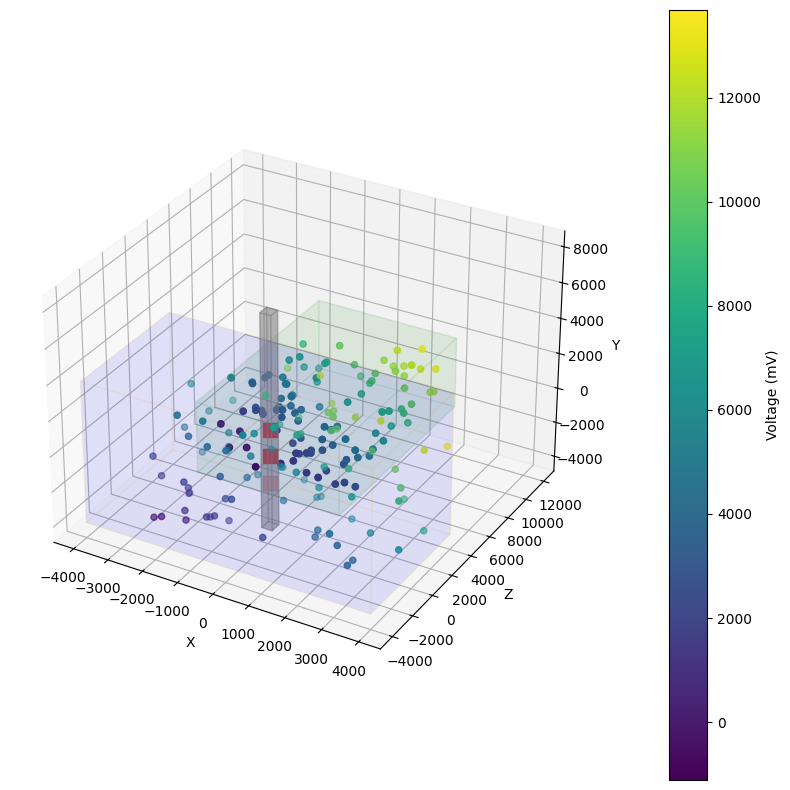

In [12]:
###### plot where the neurons are in the STn space #########
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
#%matplotlib widget

##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('X')
ax.set_ylabel('Z')
ax.set_zlabel('Y')

######## plot the cortical neuron space #############
#add the zone where there are no neurons
# Define cube vertices

# Define cube vertices
cube_vertices_ctx = np.array([
    [-4000, -4000, -4000],  # 0
    [4000, -4000, -4000],   # 1
    [4000, 4000, -4000],    # 2
    [-4000, 4000, -4000],   # 3
    [-4000, -4000, 4000],   # 4
    [4000, -4000, 4000],    # 5
    [4000, 4000, 4000],     # 6
    [-4000, 4000, 4000]     # 7
])

# Define cube faces using indices
faces = [
    [cube_vertices_ctx[i] for i in [0, 1, 2, 3]],  # bottom
    [cube_vertices_ctx[i] for i in [4, 5, 6, 7]],  # top
    [cube_vertices_ctx[i] for i in [0, 1, 5, 4]],  # front
    [cube_vertices_ctx[i] for i in [2, 3, 7, 6]],  # back
    [cube_vertices_ctx[i] for i in [1, 2, 6, 5]],  # right
    [cube_vertices_ctx[i] for i in [0, 3, 7, 4]]   # left
]

ax.add_collection3d(Poly3DCollection(faces, facecolors='blue', alpha=0.05, linewidths=1, edgecolor = 'orange', label = "Cortical space"))

######## plot the STN neuron space ################
#add the zone where there are no neurons
# Define cube vertices

# Define cube faces using the vertices
# Define cube vertices
cube_vertices_stn = np.array([
    [-2000, -6000+6000, -2000],  # point 0
    [2000, -6000+6000, -2000],  # point 1
    [2000, 6000+6000, -2000],  # point 2
    [-2000, 6000+6000, -2000],  # point 3
    [-2000, -6000+6000, 2000],  # point 0
    [2000, -6000+6000, 2000],  # point 1
    [2000, 6000+6000, 2000],  # point 2
    [-2000, 6000+6000, 2000],  # po
])

# Define cube faces using the vertices
faces = [
    [cube_vertices_stn[i] for i in [0, 1, 2, 3]],  # bottom
    [cube_vertices_stn[i] for i in [4, 5, 6, 7]],  # top
    [cube_vertices_stn[i] for i in [0, 1, 5, 4]],  # front
    [cube_vertices_stn[i] for i in [2, 3, 7, 6]],  # back
    [cube_vertices_stn[i] for i in [1, 2, 6, 5]],  # right
    [cube_vertices_stn[i] for i in [0, 3, 7, 4]]   # left
]

ax.add_collection3d(Poly3DCollection(faces, facecolors='green', alpha=0.05, linewidths=1, edgecolor = 'green', label = "STN space"))

########### add in the no-go space - remember physically y <-> z ############################
# x limin -150 < x < 150
#y limiit -4000< y < 4000
# z limit -317.5 < z < 317.5

#offset the cube vertices z coordinate by 250 because thats where the electrode is

#for show I have the electrode coming out the top of the STN space

cube_vertices = np.array([
    [-150.0, -317.5+250, -4000],  # point 0
    [ 150.0, -317.5+250, -4000],  # point 1
    [ 150.0,  317.5+250, -4000],  # point 2
    [-150.0,  317.5+250, -4000],  # point 3
    [-150.0, -317.5+250,  8000],  # point 4
    [ 150.0, -317.5+250,  8000],  # point 5
    [ 150.0,  317.5+250,  8000],  # point 6
    [-150.0,  317.5+250,  8000],  # point 7
])

# Define cube faces using the vertices
faces = [
    [cube_vertices[i] for i in [0, 1, 2, 3]],  # bottom
    [cube_vertices[i] for i in [4, 5, 6, 7]],  # top
    [cube_vertices[i] for i in [0, 1, 5, 4]],  # front
    [cube_vertices[i] for i in [2, 3, 7, 6]],  # back
    [cube_vertices[i] for i in [1, 2, 6, 5]],  # right
    [cube_vertices[i] for i in [0, 3, 7, 4]]   # left
]

ax.add_collection3d(Poly3DCollection(faces, facecolors='gray', alpha=0.35, linewidths=1, edgecolor = 'gray', label = "No-Go Zone"))

##########plot the stimulating electrode - remember y <-> z###########
ax.scatter(0, 250, 0, c='red', s=100, marker = "s")
#plot the receiving electrode
ax.scatter([0,0], [250,250], [-1500,1500], c='red', s=100, marker = "s", label = "Electrodes")


#Using the fake COMSOL data from before - create the interpolation function
column_names = ['x', 'y', 'z', 'V']
df = pd.read_csv('exStimVoltProf.txt', names=column_names, comment='%', delim_whitespace=True)
x = np.array(df.x.to_list())
y = np.array(df.y.to_list())
z = np.array(df.z.to_list())
points = np.array([x,y,z]).T
V = np.array(df.V.to_list())

Vint = LinearNDInterpolator(points, V)

#interpolate the values for the ctx neurons
x_points_clean_ctx = cortical_pop.positions[0]
y_points_clean_ctx = cortical_pop.positions[1]
z_points_clean_ctx = cortical_pop.positions[2]
interpolated_values_ctx = Vint(np.column_stack((x_points_clean_ctx, z_points_clean_ctx, y_points_clean_ctx)))
ax.scatter(x_points_clean_ctx, z_points_clean_ctx, y_points_clean_ctx, c=interpolated_values_ctx)

#interpolate the values for the stn neurons
x_points_clean_stn = STN_pop.positions[0]
y_points_clean_stn = STN_pop.positions[1]
z_points_clean_stn = STN_pop.positions[2]
interpolated_values_stn = Vint(np.column_stack((x_points_clean_stn, z_points_clean_stn, y_points_clean_stn)))
ax.scatter(x_points_clean_stn, z_points_clean_stn, y_points_clean_stn, c=interpolated_values_stn)


#add a colour bar
cbar = plt.colorbar(ax.scatter(x_points_clean_stn,z_points_clean_stn,y_points_clean_stn, c=interpolated_values_stn, cmap='viridis'), pad=0.1)
cbar.set_label('Voltage (mV)')  # label for the colorbar

plt.show()

/tmp/ipykernel_5484/140324871.py:10: UserWarning: Adding colorbar to a different Figure <Figure size 1000x1000 with 3 Axes> than <Figure size 900x400 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(ax.scatter(x,y,z, c=V, cmap='viridis'), pad=0.25)


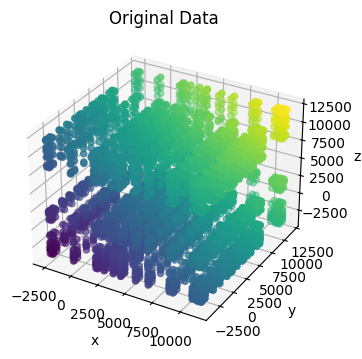

In [9]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_title("Original Data")
ax1.scatter(x, y, z, c=V, cmap='viridis')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')

#add a colour bar
cbar = plt.colorbar(ax.scatter(x,y,z, c=V, cmap='viridis'), pad=0.25)
cbar.set_label('Voltage (mV)')  # label for the colorbar